In [2]:
import os
import time
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import fsolve
from scipy.integrate import solve_ivp

%matplotlib inline
plt.style.use('seaborn-bright')
plt.rcParams.update({'font.size': 18})

/tmp/ipykernel_435521/2154713450.py:12: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-bright')


In [3]:
# Non-Linear Functions
def f(x, beta, gamma, theta):
    return 1 / (1 + np.exp(-beta * gamma * (x - theta)))

def Fvect(x, **opts):
    vmin = -1 / opts.get('gamma'); vmax = 1 / opts.get('gamma')
    nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)
    sigmoid_vals = f(x + v, opts.get('beta'), opts.get('gamma'), opts.get('theta'))
    normal_vals = np.exp(-v ** 2 / (2 * opts.get('sigma') ** 2)) / np.sqrt(2 * np.pi * opts.get('sigma') ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [4]:
def DualNodeModel(x, t, **opts):
    gamma = opts.get('gamma')

    e1_opts = {'beta': opts.get('bE1'), 'gamma': gamma, 'theta': opts.get('thetaE1'), 'sigma': opts.get('sigmaE1')}
    i1_opts = {'beta': opts.get('bI1'), 'gamma': gamma, 'theta': opts.get('thetaI1'), 'sigma': opts.get('sigmaI1')}
    e2_opts = {'beta': opts.get('bE2'), 'gamma': gamma, 'theta': opts.get('thetaE2'), 'sigma': opts.get('sigmaE2')}
    i2_opts = {'beta': opts.get('bI2'), 'gamma': gamma, 'theta': opts.get('thetaI2'), 'sigma': opts.get('sigmaI2')}

    dE1dt = opts.get('alphaE1') * (-x[0] + opts.get('wee1') / gamma * Fvect(x[0], **e1_opts) + \
                                   opts.get('wie1') / gamma  * Fvect(x[1], **i1_opts) + opts.get('i_e1') / gamma  + \
                                   opts.get('K1') * x[2] - opts.get('K2') * x[3]
                                   )

    dI1dt = opts.get('alphaI1') * (-x[1] + opts.get('wei1') / gamma  * Fvect(x[0], **e1_opts) + \
                                   opts.get('wii1') / gamma  * Fvect(x[1], **i1_opts) + opts.get('i_i1') / gamma  + \
                                   opts.get('K3') * x[2] - opts.get('K4') * x[3]
                                   )

    dE2dt = opts.get('alphaE2') * (-x[2] + opts.get('wee2') / gamma  * Fvect(x[2], **e2_opts) + \
                                   opts.get('wie2') / gamma  * Fvect(x[3], **i2_opts) + opts.get('i_e2') / gamma  + \
                                   opts.get('K1') * x[0] - opts.get('K2') * x[1]
                                   )

    dI2dt = opts.get('alphaI2') * (-x[3] + opts.get('wei2') / gamma  * Fvect(x[2], **e2_opts) + \
                                   opts.get('wii2') / gamma  * Fvect(x[3], **i2_opts) + opts.get('i_i2') / gamma  + \
                                   opts.get('K3') * x[0] - opts.get('K4') * x[1]
                                   )

    return [dE1dt, dI1dt, dE2dt, dI2dt]

In [5]:
def fixedpoints(minval, maxval, resolution = 75, nsamples = 20, cal_grad = False, **opts):
    # Set up the 4-D space
    x0 = np.linspace(minval, maxval, resolution)
    x1 = np.linspace(minval, maxval, resolution)
    x2 = np.linspace(minval, maxval, resolution)
    x3 = np.linspace(minval, maxval, resolution)

    x0, x1, x2, x3 = np.meshgrid(x0, x1, x2, x3)

    # Evaluate the gradients
    if cal_grad:
        grad0, grad1, grad2, grad3 = DualNodeModel([x0, x1, x2, x3], 0, **opts)
        print('Gradients calculated')
    else:
        grad0, grad1, grad2, grad3 = None, None, None, None
    # Numerical search for fixed points
    fixed_points = []
    y0 = x0.ravel()
    y1 = x1.ravel()
    y2 = x2.ravel()
    y3 = x3.ravel()

    inits = random.sample(list(np.arange(0, resolution ** 4)), k = nsamples)

    for k in inits:
        # find the root
        sol, _, ier, msg = fsolve(lambda y: DualNodeModel(y, 0, **opts), [y0[k], y1[k], y2[k], y3[k]], full_output=1)
        if ier == 1:       # Exclude the cases where fsolve didn't converge
            fixed_points.append(sol)

    fixed_points = np.array(fixed_points).T
    fixed_points = np.array(list(set(map(tuple, np.around(fixed_points, 4).T))))   # Unique fixed points
    # print("Finished fixed point calculations!")

    return_dict = {
                    'locs': [x0, x1, x2, x3],
                    'grads': [grad0, grad1, grad2, grad3],
                    'fixed': fixed_points.T
    }
    return return_dict

In [6]:
def plot_traj(grid_min, grid_max, ode_solves, init_points, plot_dim, fig_size = (5, 5), **res_dict):
    dim_labels = [r'$E_1$', r'$I_1$', r'$E_2$', r'$I_2$']
    assert type(plot_dim) == list and len(plot_dim) == 2, "Wrong dims to plot"

    dim0, dim1 = res_dict.get('locs')[plot_dim[0]], res_dict.get('locs')[plot_dim[1]]
    grad0, grad1 = res_dict.get('grads')[plot_dim[0]], res_dict.get('grads')[plot_dim[1]]
    fp = res_dict.get('fixed')

    if (plot_dim[0] == 0 or plot_dim[0] == 1):
        dim0 = dim0[:, :, 0, 0]
        grad0 = grad0[:, :, 0, 0]
    elif (plot_dim[0] == 2 or plot_dim[0] == 3):
        dim0 = dim0[0, 0, :, :]
        grad0 = grad0[0, 0, :, :]

    if (plot_dim[1] == 0 or plot_dim[1] == 1):
        dim1 = dim1[:, :, 0, 0]
        grad1 = grad1[:, :, 0, 0]
    elif (plot_dim[1] == 2 or plot_dim[1] == 3):
        dim1 = dim1[0, 0, :, :]
        grad1 = grad1[0, 0, :, :]

    xlabel = dim_labels[plot_dim[1]]
    ylabel = dim_labels[plot_dim[0]]

    # Plotting the vector field in the state space (E, I)
    plt.figure(figsize = fig_size)
    plt.quiver(dim1, dim0, grad1, grad0, pivot='mid', alpha=.8)
    plt.xlim([grid_min, grid_max]); plt.ylim([grid_min, grid_max])
    plt.xlabel(xlabel, fontsize=16); plt.ylabel(ylabel, fontsize=16)
    plt.grid()

    ninits, sys_dim, _ = ode_solves.shape

    x0_, x1_, x2_, x3_ = init_points

    for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
        xSolve = ode_solves[k, :, :]
        xdim0, xdim1 = xSolve[plot_dim]
        # Plot the solution in the state space
        plt.plot(xdim1, xdim0, '-', )

        # Plot the starting point
        plt.scatter(y0[plot_dim[1]], y0[plot_dim[0]], marker='*', c='r', s=300, label=f"{ylabel} = {y0[plot_dim[0]]:.3f} {xlabel} = {y0[plot_dim[1]]:.3f}")

    # Plot the fixed points identified
    plt.scatter(fp[plot_dim[1]], fp[plot_dim[0]], marker='o', c='k', s=100, label="Stationary points")
    plt.legend(loc='upper left')
    plt.show()
    return

In [7]:
def plot_timeseries(x, time_, sigmas):
    # Plot the solution in time
    plt.figure(figsize=(10.3,6))
    plt.subplot(4,1,1)
    plt.ylabel(r'$E_1$'); plt.xlabel(r'$t$')
    plt.xlim([0, 250])
    plt.plot(time_, np.mean(x[:, 0, :], axis=0), '-', label="excitatory")
    plt.xlim([time_[0], time_[-1]])
    plt.title(f'Population 01 :: Excitatory Dynamics (\u03C3e = {sigmas[0]})')

    plt.subplot(4,1,2)
    plt.ylabel(r'$I_1$'); plt.xlabel(r'$t$')
    plt.xlim([0, 250])
    plt.plot(time_, np.mean(x[:, 1, :], axis=0), '-', label="inhibitory")
    plt.xlim([time_[0], time_[-1]])
    plt.title(f'Population 01 :: Inhibitory Dynamics (\u03C3i = {sigmas[1]})')

    plt.subplot(4,1,3)
    plt.ylabel(r'$E_2$'); plt.xlabel(r'$t$')
    plt.xlim([0, 250])
    plt.plot(time_, np.mean(x[:, 2, :], axis=0), '-', label="excitatory")
    plt.xlim([time_[0], time_[-1]])
    plt.title(f'Population 02 :: Excitatory Dynamics (\u03C3e = {sigmas[2]})')

    plt.subplot(4,1,4)
    plt.ylabel(r'$I_2$'); plt.xlabel(r'$t$')
    plt.xlim([0, 250])
    plt.plot(time_, np.mean(x[:, 3, :], axis=0), '-', label="inhibitory");
    plt.title(f'Population 02 :: Inhibitory Dynamics (\u03C3i = {sigmas[3]})')
    plt.xlim([time_[0], time_[-1]])
    plt.tight_layout()
    plt.show()
    return

## System Analysis using Jacobian and Eigen Values

In [8]:
def fprime(x, beta, gamma, theta):
    return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)

def Fprime(x, **opts):
    gamma = opts.get('gamma')

    vmin = -1 / gamma; vmax = 1 / gamma;
    nsteps = 1000
    dv = np.abs(vmax - vmin) / nsteps
    v = np.arange(vmin, vmax, dv)

    if type(x) == np.ndarray and len(x.shape) == 4:
        x = np.repeat(x[:, :, :, :, np.newaxis], nsteps, axis=4)

    sigmoid_vals = fprime(x + v, opts.get('beta'), opts.get('gamma'), opts.get('theta'))
    normal_vals = np.exp(-v ** 2 / (2 * opts.get('sigma') ** 2)) / np.sqrt(2 * np.pi * opts.get('sigma') ** 2)

    return np.sum(dv * sigmoid_vals * normal_vals, axis=-1)

In [9]:
def Jacobian(fixed_points, **opts):
    analysis_results = {
                        'eigvals': [],
                        'types': []
                    }

    gamma = opts.get('gamma')

    e1_opts = {'beta': opts.get('bE1'), 'gamma': gamma, 'theta': opts.get('thetaE1'), 'sigma': opts.get('sigmaE1')}
    i1_opts = {'beta': opts.get('bI1'), 'gamma': gamma, 'theta': opts.get('thetaI1'), 'sigma': opts.get('sigmaI1')}
    e2_opts = {'beta': opts.get('bE2'), 'gamma': gamma, 'theta': opts.get('thetaE2'), 'sigma': opts.get('sigmaE2')}
    i2_opts = {'beta': opts.get('bI2'), 'gamma': gamma, 'theta': opts.get('thetaI2'), 'sigma': opts.get('sigmaI2')}

    # Jacobian Analysis
    for i, (fE1, fI1, fE2, fI2) in enumerate(fixed_points):
        # print(f"Fixed point :: ({fE1}, {fI1}, {fE2}, {fI2}) --> ", end='')
        J = np.zeros((4, 4))

        J[0,0] = opts['alphaE1'] * (-1 + opts['wee1'] / gamma * Fprime(fE1, **e1_opts))
        J[0,1] = opts['alphaE1'] * opts['wie1'] / gamma * Fprime(fI1, **i1_opts)
        J[0,2] = opts['alphaE1'] * opts['K1']
        J[0,3] = opts['alphaE1'] * -opts['K2']

        J[1,0] = opts['alphaI1'] * opts['wei1'] / gamma * Fprime(fE1, **e1_opts)
        J[1,1] = opts['alphaI1'] * (-1 + opts['wii1'] / gamma * Fprime(fI1, **i1_opts))
        J[1,2] = opts['alphaI1'] * opts['K3']
        J[1,3] = opts['alphaI1'] * -opts['K4']

        J[2,0] = opts['alphaE2'] * opts['K1']
        J[2,1] = opts['alphaE2'] * -opts['K2']
        J[2,2] = opts['alphaE2'] * (-1 + opts['wee2'] / gamma * Fprime(fE2, **e2_opts))
        J[2,3] = opts['alphaE2'] * opts['wie2'] / gamma * Fprime(fI2, **i2_opts)

        J[3,0] = opts['alphaI2'] * opts['K3']
        J[3,1] = opts['alphaI2'] * -opts['K4']
        J[3,2] = opts['alphaI2'] * opts['wei2'] / gamma * Fprime(fE2, **e2_opts)
        J[3,3] = opts['alphaI2'] * (-1 + opts['wii2'] / gamma * Fprime(fI2, **i2_opts))

        # Compute and return the eigenvalues
        if np.isnan(sum(J.flatten())) or np.isinf(sum(J.flatten())):
            return analysis_results

        evals = np.linalg.eig(J)[0]
        analysis_results['eigvals'].append(evals)

        # Analysis
        real_parts = np.real(evals).T
        img_parts = np.imag(evals).T

        if (img_parts == 0).all():
            if (real_parts > 0).all():
                analysis_results['types'].append('mediumblue')
                # print("Unstable Node")
            elif (real_parts < 0).all():
                analysis_results['types'].append('darkgreen')
                # print("Stable Node")
            else:
                analysis_results['types'].append('red')
                # print("Unstable Saddle Point")

        elif (img_parts != 0).any():
            if (real_parts < 0).all():
                analysis_results['types'].append('saddlebrown')
                # print("Stable Spiral")
            elif (real_parts > 0).any():
                analysis_results['types'].append('purple')
                # print("Unstable Spiral")
            elif (real_parts == 0).any():
                analysis_results['types'].append('black')
                # print("Circle")
    return analysis_results

In [10]:
parameters = {
                'wee1': 1.6, 'wie1': -4.7, 'wei1': 3, 'wii1': -0.13,            # intra-node parameters Node #1
                'bE1': 300, 'bI1': 300, 'thetaE1': 0.0, 'thetaI1': 0.0,
                'i_e1': -0.25 + 0.2, 'i_i1': -0.5, 'alphaE1': 1, 'alphaI1': 2,
                'sigmaE1': 7.8, 'sigmaI1': 16.25,
                'wee2': 1.6, 'wie2': -4.7, 'wei2': 3, 'wii2': -0.13,            # intra-node parameters Node #2
                'bE2': 300, 'bI2': 300, 'thetaE2': 0.0, 'thetaI2': 0.0,
                'i_e2': -0.25, 'i_i2': -0.5, 'alphaE2': 1, 'alphaI2': 2,
                'sigmaE2': 4.4, 'sigmaI2': 2.5,
                'K1': 0.0, 'K2': 0.0, 'K3': 0.0, 'K4': 0.0,                     # inter-node coupling coefficients
                'gamma': 0.016, 'D': 0.001, 'dt': 0.1, 'noise1': None, 'noise2': None,
                'Ne1': 800, 'Ni1': 200, 'Ne2': 800, 'Ni2': 200
}

time_ = np.linspace(0, 250, 2500)
grid_min = -2 / parameters['gamma']
grid_max = 2 / parameters['gamma']
resolution = 20

# Numerical ODE integration to plot trajectories
x0_ = np.random.uniform(grid_min, grid_max, 5)
x1_ = np.random.uniform(grid_min, grid_max, 5)
x2_ = np.random.uniform(grid_min, grid_max, 5)
x3_ = np.random.uniform(grid_min, grid_max, 5)

/tmp/ipykernel_435521/893043170.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))


Gradients calculated


/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in square
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Evaluating with random initialization No. 1 --> Execution time: 0.110s
Evaluating with random initialization No. 2 --> Execution time: 0.025s
Evaluating with random initialization No. 3 --> Execution time: 0.051s
Evaluating with random initialization No. 4 --> Execution time: 0.050s
Evaluating with random initialization No. 5 --> Execution time: 0.050s


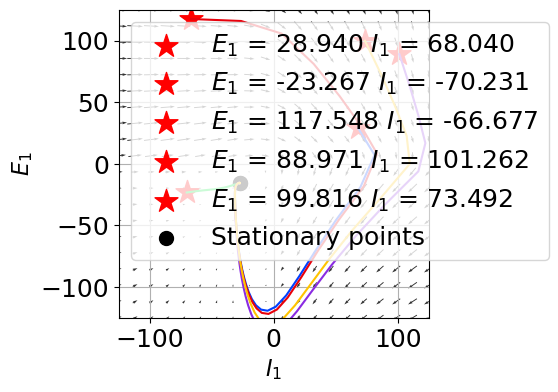

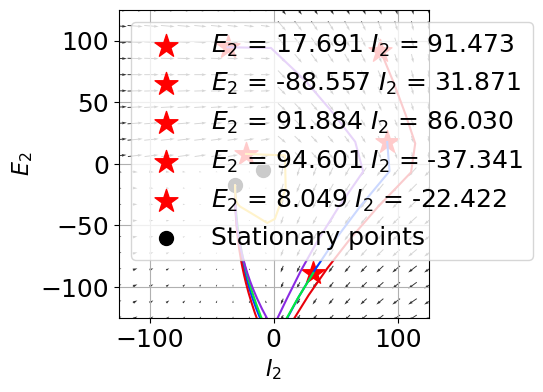

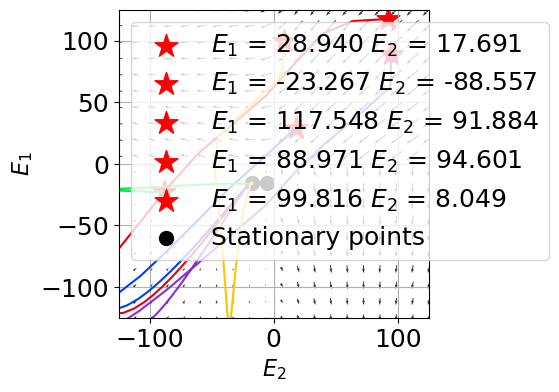

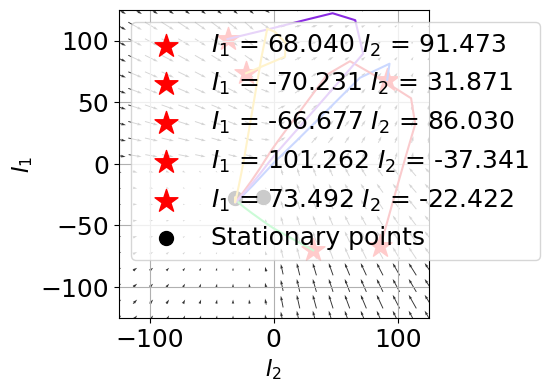

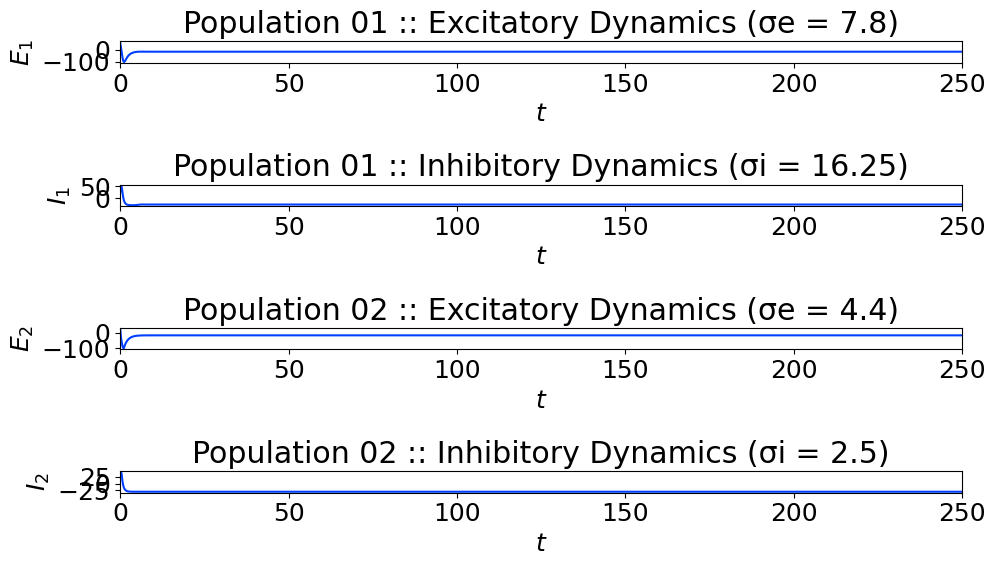

In [11]:
parameters['K1'] = 0.1
result_dict = fixedpoints(minval = grid_min, maxval = grid_max, resolution = resolution, nsamples = 50, cal_grad = True, **parameters)
analysis_dict = Jacobian(result_dict['fixed'].T, **parameters)

xensemble = np.zeros((5, 4, len(time_)))

for k, y0 in enumerate(zip(x0_, x1_, x2_, x3_)):
    tic = time.time()
    xSolve = solve_ivp(lambda t, y: DualNodeModel(y, t, **parameters), [0, time_[-1]], y0, method='BDF', t_eval=time_)
    x0Solve, x1Solve, x2Solve, x3Solve = xSolve['y']
    toc = time.time()
    print(f'Evaluating with random initialization No. {k + 1} --> Execution time: {toc - tic :.3f}s')

    xensemble[k, 0, :] = x0Solve
    xensemble[k, 1, :] = x1Solve
    xensemble[k, 2, :] = x2Solve
    xensemble[k, 3, :] = x3Solve

plot_traj(grid_min = grid_min, grid_max = grid_max, ode_solves = xensemble, init_points = [x0_, x1_, x2_, x3_],
          plot_dim = [0, 1], fig_size = (4, 4), **result_dict)
plot_traj(grid_min = grid_min, grid_max = grid_max, ode_solves = xensemble, init_points = [x0_, x1_, x2_, x3_],
          plot_dim = [2, 3], fig_size = (4, 4), **result_dict)
plot_traj(grid_min = grid_min, grid_max = grid_max, ode_solves = xensemble, init_points = [x0_, x1_, x2_, x3_],
          plot_dim = [0, 2], fig_size = (4, 4), **result_dict)
plot_traj(grid_min = grid_min, grid_max = grid_max, ode_solves = xensemble, init_points = [x0_, x1_, x2_, x3_],
          plot_dim = [1, 3], fig_size = (4, 4), **result_dict)
plot_timeseries(xensemble, time_, [parameters['sigmaE1'], parameters['sigmaI1'], parameters['sigmaE2'], parameters['sigmaI2']])

In [12]:
root_folder = "./results"
os.makedirs(root_folder, exist_ok=True)

In [13]:
K1_min = -1
K1_max = 1
Ksteps = 250

K1_range = K1_min + np.arange(0, Ksteps) / Ksteps * (K1_max - K1_min)

fixedTrack = []
fixedColors = []

parameters['i_e1'] = -0.25 + 0.2

file_str_k = f"sig_e1_{parameters['sigmaE1']:.3f}_sig_i1_{parameters['sigmaI1']:.3f}_sig_e2_{parameters['sigmaE2']:.3f}_sig_i2_{parameters['sigmaI2']:.3f}_ie_{parameters['i_e1'] / parameters['gamma']:.3f}mV.pkl"

file_name = os.path.join(root_folder, file_str_k)

if os.path.isfile(file_name):
    print("File is found! Loading the results!")
    file_content = pickle.load(open(file_name, 'rb'))
    fixedTrack = file_content['fixed_points']
    fixedColors = file_content['point_type']
else:
    print("File is not found! Running the analysis...")
    for K1_ in K1_range:
        print(f"Coupling Strength :: {K1_:.3f}")
        parameters['K1'] = K1_

        result_dict = fixedpoints(minval = grid_min, maxval = grid_max, resolution = resolution, nsamples = 50, cal_grad = False, **parameters)
        analysis_dict = Jacobian(result_dict['fixed'].T, **parameters)

        uniqfp = result_dict['fixed'].T   # Unique fixed points
        pointtypes = analysis_dict['types']

        fixedTrack.append(uniqfp)
        fixedColors.append(pointtypes)

    write_dict = {
                    'fixed_points': fixedTrack,
                    'point_type': fixedColors
    }

    with open(file_name, 'wb') as file:
        pickle.dump(write_dict, file)


File is not found! Running the analysis...
Coupling Strength :: -1.000


/tmp/ipykernel_435521/893043170.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))
/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in square
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Coupling Strength :: -0.992
Coupling Strength :: -0.984
Coupling Strength :: -0.976
Coupling Strength :: -0.968
Coupling Strength :: -0.960
Coupling Strength :: -0.952
Coupling Strength :: -0.944
Coupling Strength :: -0.936
Coupling Strength :: -0.928
Coupling Strength :: -0.920
Coupling Strength :: -0.912
Coupling Strength :: -0.904
Coupling Strength :: -0.896
Coupling Strength :: -0.888
Coupling Strength :: -0.880
Coupling Strength :: -0.872
Coupling Strength :: -0.864
Coupling Strength :: -0.856
Coupling Strength :: -0.848
Coupling Strength :: -0.840
Coupling Strength :: -0.832
Coupling Strength :: -0.824
Coupling Strength :: -0.816
Coupling Strength :: -0.808
Coupling Strength :: -0.800
Coupling Strength :: -0.792
Coupling Strength :: -0.784
Coupling Strength :: -0.776
Coupling Strength :: -0.768
Coupling Strength :: -0.760
Coupling Strength :: -0.752
Coupling Strength :: -0.744
Coupling Strength :: -0.736
Coupling Strength :: -0.728
Coupling Strength :: -0.720
Coupling Strength ::

/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in exp
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)
/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in multiply
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)
/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: invalid value encountered in divide
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Coupling Strength :: 0.856
Coupling Strength :: 0.864
Coupling Strength :: 0.872
Coupling Strength :: 0.880
Coupling Strength :: 0.888
Coupling Strength :: 0.896
Coupling Strength :: 0.904
Coupling Strength :: 0.912
Coupling Strength :: 0.920
Coupling Strength :: 0.928
Coupling Strength :: 0.936
Coupling Strength :: 0.944
Coupling Strength :: 0.952
Coupling Strength :: 0.960
Coupling Strength :: 0.968
Coupling Strength :: 0.976
Coupling Strength :: 0.984
Coupling Strength :: 0.992


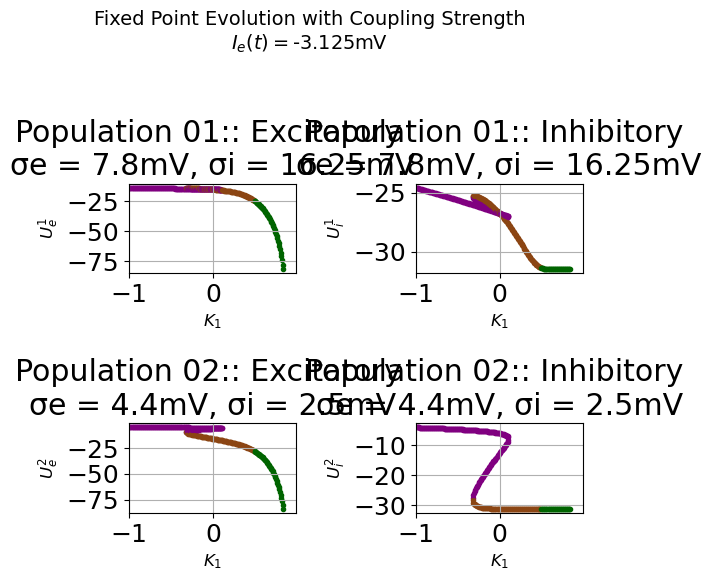

In [14]:
fig, axs = plt.subplots(2, 2, figsize=(6,6))
parameters['i_e1'] = -0.25 + 0.2
for k in range(min(len(fixedColors), len(fixedTrack))):
    fixed_point = fixedTrack[k]
    fixed_color = fixedColors[k]

    for fp, color in zip(fixed_point, fixed_color):
        axs[0][0].scatter(K1_range[k], fp[0], marker='.', c = color)
        axs[0][1].scatter(K1_range[k], fp[1], marker='.', c = color)
        axs[1][0].scatter(K1_range[k], fp[2], marker='.', c = color)
        axs[1][1].scatter(K1_range[k], fp[3], marker='.', c = color)

axs[0][0].set_xlim([K1_min, K1_range[k]])
axs[0][0].set_ylabel(r"$U_e^1$", fontsize=12); axs[0][0].set_xlabel(r"$K_1$", fontsize=12)
axs[0][0].set_title(f"Population 01:: Excitatory \n\u03C3e = {parameters['sigmaE1']}mV, \u03C3i = {parameters['sigmaI1']}mV")
axs[0][0].grid()

axs[0][1].set_xlim([K1_min, K1_range[k]])
axs[0][1].set_ylabel(r"$U_i^1$", fontsize=12); axs[0][1].set_xlabel(r"$K_1$", fontsize=12)
axs[0][1].set_title(f"Population 01:: Inhibitory \n\u03C3e = {parameters['sigmaE1']}mV, \u03C3i = {parameters['sigmaI1']}mV")
axs[0][1].grid()

axs[1][0].set_xlim([K1_min, K1_range[k]])
axs[1][0].set_ylabel(r"$U_e^2$", fontsize=12); axs[1][0].set_xlabel(r"$K_1$", fontsize=12)
axs[1][0].set_title(f"Population 02:: Excitatory \n\u03C3e = {parameters['sigmaE2']}mV, \u03C3i = {parameters['sigmaI2']}mV")
axs[1][0].grid()

axs[1][1].set_xlim([K1_min, K1_range[k]])
axs[1][1].set_ylabel(r"$U_i^2$", fontsize=12); axs[1][1].set_xlabel(r"$K_1$", fontsize=12)
axs[1][1].set_title(f"Population 02:: Inhibitory \n\u03C3e = {parameters['sigmaE2']}mV, \u03C3i = {parameters['sigmaI2']}mV")
axs[1][1].grid()

fig.suptitle(f'Fixed Point Evolution with Coupling Strength\n'+r"$I_e(t) = $"+f"{parameters['i_e1']/parameters['gamma']:.3f}mV\n", fontsize=14)
fig.tight_layout()

fig.savefig(os.path.join(root_folder, os.path.basename(file_str_k) +'.png'))

In [16]:
Isteps = 250
Imax = 0.25; Imin = -0.25
fixedTrack = []
fixedColors = []

parameters['K1'] = 0.5

file_str_ie = f"sig_e1_{parameters['sigmaE1']:.3f}_sig_i1_{parameters['sigmaI1']:.3f}_sig_e2_{parameters['sigmaE2']:.3f}_sig_i2_{parameters['sigmaI2']:.3f}_K1_{parameters['K1']:.3f}.pkl"

file_name = os.path.join(root_folder, file_str_ie)

if os.path.isfile(file_name):
    print("File is found! Loading the results!")
    file_content = pickle.load(open(file_name, 'rb'))
    fixedTrack = file_content['fixed_points']
    fixedColors = file_content['point_type']
else:
    print("File is not found! Running the analysis...")
    for I in range(Isteps):
        iet = I / Isteps * (Imax - Imin)
        parameters['i_e1'] = Imin + iet
        print(r"Evaluating Fixed Points for $I_e(t) = $"+f"{parameters['i_e1'] / parameters['gamma']:.3f}mV")

        result_dict = fixedpoints(minval = grid_min, maxval = grid_max, resolution = resolution, nsamples = 50, **parameters)
        analysis_dict = Jacobian(result_dict['fixed'].T, **parameters)

        uniqfp = result_dict['fixed'].T   # Unique fixed points
        pointtypes = analysis_dict['types']

        fixedTrack.append(uniqfp)
        fixedColors.append(pointtypes)
    write_dict = {
                'fixed_points': fixedTrack,
                'point_type': fixedColors
                }

    with open(file_name, 'wb') as file:
        pickle.dump(write_dict, file)

File is not found! Running the analysis...
Evaluating Fixed Points for $I_e(t) = $-15.625mV


/tmp/ipykernel_435521/893043170.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))
/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in square
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Evaluating Fixed Points for $I_e(t) = $-15.500mV
Evaluating Fixed Points for $I_e(t) = $-15.375mV
Evaluating Fixed Points for $I_e(t) = $-15.250mV
Evaluating Fixed Points for $I_e(t) = $-15.125mV
Evaluating Fixed Points for $I_e(t) = $-15.000mV
Evaluating Fixed Points for $I_e(t) = $-14.875mV
Evaluating Fixed Points for $I_e(t) = $-14.750mV
Evaluating Fixed Points for $I_e(t) = $-14.625mV
Evaluating Fixed Points for $I_e(t) = $-14.500mV
Evaluating Fixed Points for $I_e(t) = $-14.375mV
Evaluating Fixed Points for $I_e(t) = $-14.250mV
Evaluating Fixed Points for $I_e(t) = $-14.125mV
Evaluating Fixed Points for $I_e(t) = $-14.000mV
Evaluating Fixed Points for $I_e(t) = $-13.875mV
Evaluating Fixed Points for $I_e(t) = $-13.750mV
Evaluating Fixed Points for $I_e(t) = $-13.625mV
Evaluating Fixed Points for $I_e(t) = $-13.500mV
Evaluating Fixed Points for $I_e(t) = $-13.375mV
Evaluating Fixed Points for $I_e(t) = $-13.250mV
Evaluating Fixed Points for $I_e(t) = $-13.125mV
Evaluating Fixed Poi

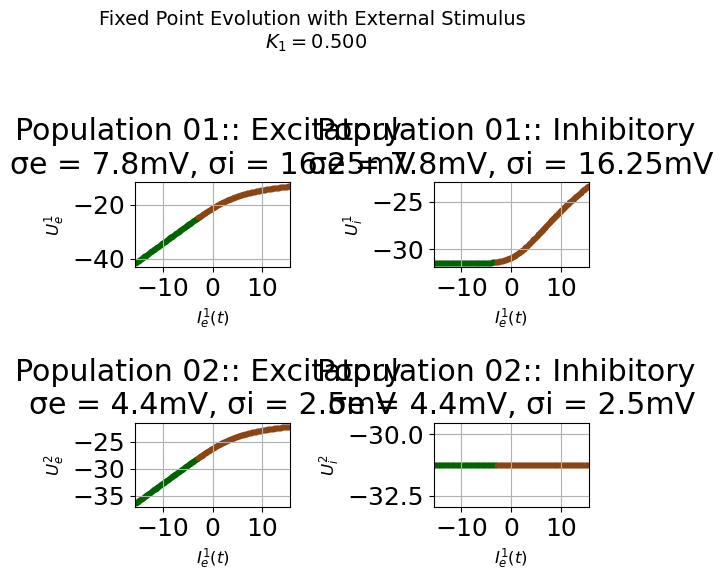

In [17]:
Iet_seq = (Imin + np.arange(0, Isteps) / Isteps * (Imax - Imin)) / parameters['gamma']

fig, axs = plt.subplots(2, 2, figsize=(6,6))

for k in range(Isteps):
    fixed_point = fixedTrack[k]
    fixed_color = fixedColors[k]

    for fp, color in zip(fixed_point, fixed_color):
        axs[0][0].scatter(Iet_seq[k], fp[0], marker='.', c = color)
        axs[0][1].scatter(Iet_seq[k], fp[1], marker='.', c = color)
        axs[1][0].scatter(Iet_seq[k], fp[2], marker='.', c = color)
        axs[1][1].scatter(Iet_seq[k], fp[3], marker='.', c = color)

axs[0][0].set_xlim([Imin / parameters['gamma'], Imax / parameters['gamma']])
axs[0][0].set_ylabel(r"$U_e^1$", fontsize=12); axs[0][0].set_xlabel(r"$I_e^1(t)$", fontsize=12)
axs[0][0].set_title(f"Population 01:: Excitatory \n\u03C3e = {parameters['sigmaE1']}mV, \u03C3i = {parameters['sigmaI1']}mV")
axs[0][0].grid()

axs[0][1].set_xlim([Imin / parameters['gamma'], Imax / parameters['gamma']])
axs[0][1].set_ylabel(r"$U_i^1$", fontsize=12); axs[0][1].set_xlabel(r"$I_e^1(t)$", fontsize=12)
axs[0][1].set_title(f"Population 01:: Inhibitory \n\u03C3e = {parameters['sigmaE1']}mV, \u03C3i = {parameters['sigmaI1']}mV")
axs[0][1].grid()

axs[1][0].set_xlim([Imin / parameters['gamma'], Imax / parameters['gamma']])
axs[1][0].set_ylabel(r"$U_e^2$", fontsize=12); axs[1][0].set_xlabel(r"$I_e^1(t)$", fontsize=12)
axs[1][0].set_title(f"Population 02:: Excitatory \n\u03C3e = {parameters['sigmaE2']}mV, \u03C3i = {parameters['sigmaI2']}mV")
axs[1][0].grid()

axs[1][1].set_xlim([Imin / parameters['gamma'], Imax / parameters['gamma']])
axs[1][1].set_ylabel(r"$U_i^2$", fontsize=12); axs[1][1].set_xlabel(r"$I_e^1(t)$", fontsize=12)
axs[1][1].set_title(f"Population 02:: Inhibitory \n\u03C3e = {parameters['sigmaE2']}mV, \u03C3i = {parameters['sigmaI2']}mV")
axs[1][1].grid()

fig.suptitle(f'Fixed Point Evolution with External Stimulus \n'+r"$K_1 = $"+f"{parameters['K1']:.3f}\n", fontsize=14)
fig.tight_layout()

fig.savefig(os.path.join(root_folder, os.path.basename(file_str_ie)+'.png'))

In [19]:
write_dict = {
                'fixed_points': [],
                'point_type': []
            }

Imin = -0.25
Imax = 0.25
Isteps = 50

K1_min = -1
K1_max = 1
Ksteps = 50

K1_range = K1_min + np.arange(0, Ksteps) / Ksteps * (K1_max - K1_min)

file_str = f"sig_e1_{parameters['sigmaE1']:.3f}_sig_i1_{parameters['sigmaI1']:.3f}_sig_e2_{parameters['sigmaE2']:.3f}_sig_i2_{parameters['sigmaI2']:.3f}_3D.pkl"
file_name = os.path.join(root_folder, file_str)

if os.path.isfile(file_name):
    print("File is found! Loading the results!")
    write_dict = pickle.load(open(file_name, 'rb'))

else:
    print("File is not found! Running the analysis...")
    for K1_ in K1_range:
        print(f"Coupling Strength :: {K1_:.3f}")
        parameters['K1'] = K1_

        fixedTrack = []
        fixedColors = []

        for I in range(Isteps):
            iet = I / Isteps * (Imax - Imin)

            parameters['i_e1'] = Imin + iet
            # print(r"Evaluating Fixed Points for $I_e(t) = $"+f"{parameters['i_e1'] / parameters['gamma']:.3f}mV")

            result_dict = fixedpoints(minval = grid_min, maxval = grid_max, resolution = resolution, nsamples = 80, cal_grad = False, **parameters)
            analysis_dict = Jacobian(result_dict['fixed'].T, **parameters)

            uniqfp = result_dict['fixed'].T   # Unique fixed points
            pointtypes = analysis_dict['types']

            fixedTrack.append(uniqfp)
            fixedColors.append(pointtypes)

        write_dict['fixed_points'].append(fixedTrack)
        write_dict['point_type'].append(fixedColors)

    with open(file_name, 'wb') as file:
        pickle.dump(write_dict, file)

File is found! Loading the results!


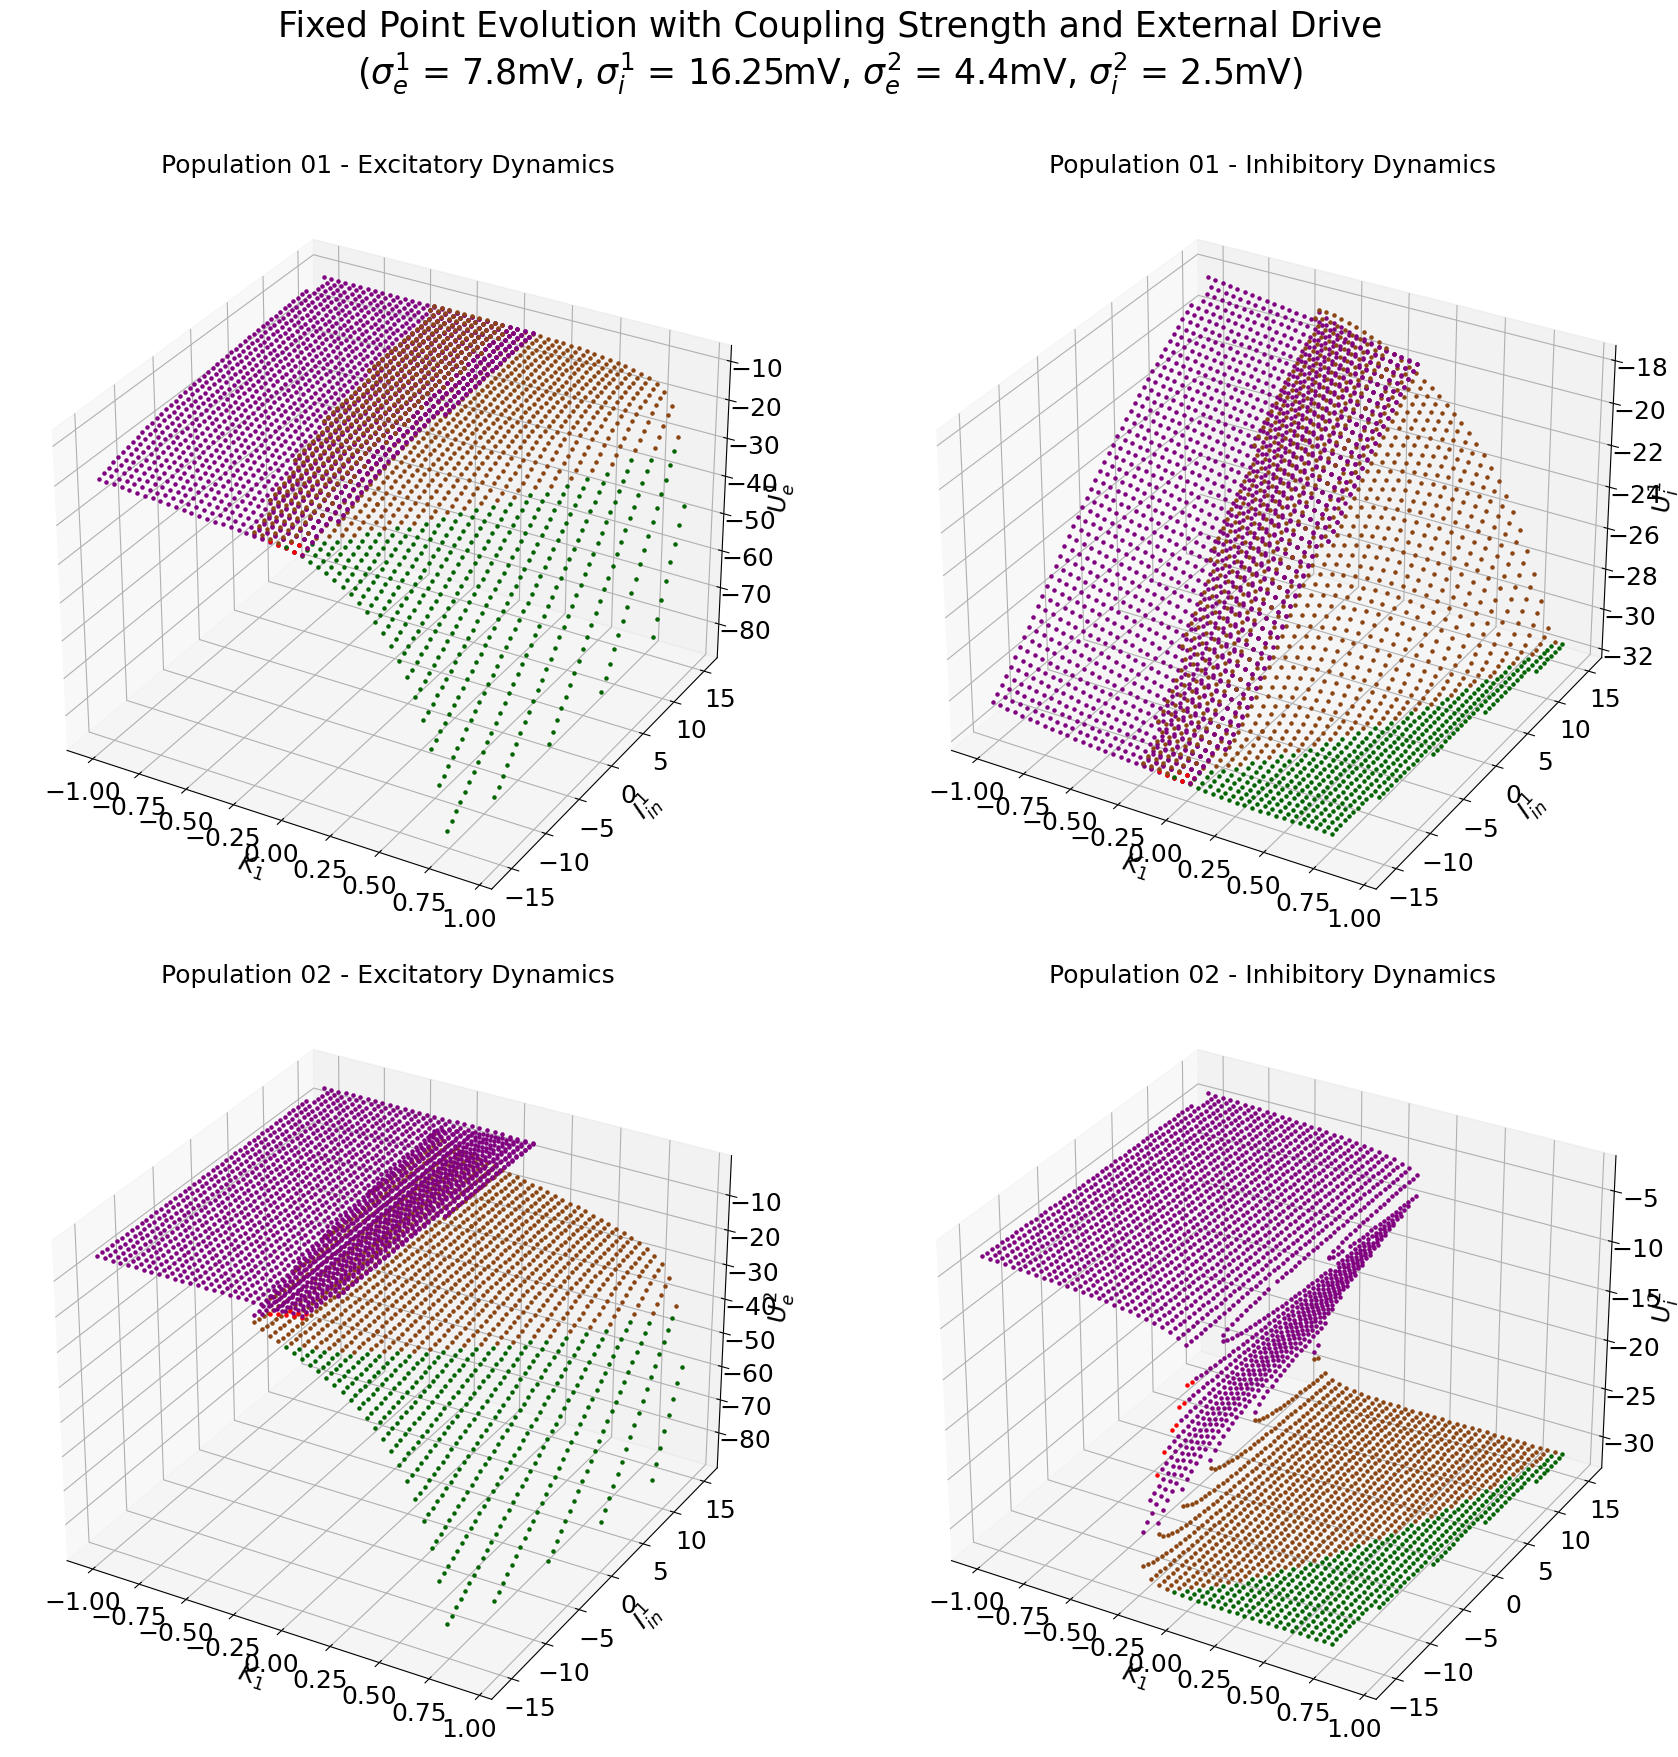

In [20]:
Imin = -0.25
Imax = 0.25
Iet_seq = (Imin + np.arange(0, Isteps) / Isteps * (Imax - Imin)) / parameters['gamma']

fig = plt.figure(figsize = (18, 18))
ax1 = fig.add_subplot(2, 2, 1, projection = '3d')
ax2 = fig.add_subplot(2, 2, 2, projection = '3d')
ax3 = fig.add_subplot(2, 2, 3, projection = '3d')
ax4 = fig.add_subplot(2, 2, 4, projection = '3d')

for k in range(Ksteps):
    for i in range(Isteps):
        fixed_point = write_dict['fixed_points'][k][i]
        fixed_color = write_dict['point_type'][k][i]

        for fp, color in zip(fixed_point, fixed_color):
            sct1 = ax1.scatter3D(K1_range[k], Iet_seq[i], fp[0], marker='.', c = color)
            sct2 = ax2.scatter3D(K1_range[k], Iet_seq[i], fp[1], marker='.', c = color)
            sct3 = ax3.scatter3D(K1_range[k], Iet_seq[i], fp[2], marker='.', c = color)
            sct4 = ax4.scatter3D(K1_range[k], Iet_seq[i], fp[3], marker='.', c = color)

ax1.set_xlabel(r'$K_1$', fontsize=18); ax1.set_ylabel(r'$I_{in}^1$', fontsize=18); ax1.set_zlabel(r'$U_e^1$', fontsize=18)
ax1.set_title(f"Population 01 - Excitatory Dynamics", fontsize = 18)

ax2.set_xlabel(r'$K_1$', fontsize=18); ax2.set_ylabel(r'$I_{in}^1$', fontsize=18); ax2.set_zlabel(r'$U_i^1$', fontsize=18)
ax2.set_title(f"Population 01 - Inhibitory Dynamics", fontsize = 18)

ax3.set_xlabel(r'$K_1$', fontsize=18); ax3.set_ylabel(r'$I_{in}^1$', fontsize=18); ax3.set_zlabel(r'$U_e^2$', fontsize=18)
ax3.set_title(f"Population 02 - Excitatory Dynamics", fontsize = 18)

ax4.set_xlabel(r'$K_1$', fontsize=18); ax1.set_ylabel(r'$I_{in}^1$', fontsize=18); ax4.set_zlabel(r'$U_i^2$', fontsize=18)
ax4.set_title(f"Population 02 - Inhibitory Dynamics", fontsize = 18)

fig.suptitle(f"Fixed Point Evolution with Coupling Strength and External Drive\n" +
            r"($\sigma_e^1$ = " + f"{parameters['sigmaE1']}mV, " + r"$\sigma_i^1$ = " +
            f"{parameters['sigmaI1']}mV, " + r"$\sigma_e^2$ = " + f"{parameters['sigmaE2']}mV, " +
            r"$\sigma_i^2$ = " + f"{parameters['sigmaI2']}mV)\n", fontsize = 25)
fig.tight_layout()
fig.savefig(os.path.join(root_folder, '.'.join(file_str.split('.')[:-1])+'.png'))

In [24]:
write_dict = {
                'fixed_points': [],
                'point_type': []
            }

heterosteps = 50
sigma_min = 2.5
sigma_max = 17.5

sigma_rng = np.linspace(sigma_min, sigma_max, heterosteps)

parameters['K1'] = 0.2
parameters['i_e1'] = 0.25
parameters['sigmaI1'] = 2.5

file_str = f"sig_i1_{parameters['sigmaI1']:.3f}_sig_i2_{parameters['sigmaI2']:.3f}_K1_{parameters['K1']:.3f}_ie1_{parameters['i_e1']:.3f}_3D.pkl"
file_name = os.path.join(root_folder, file_str)

if os.path.isfile(file_name):
    print("File is found! Loading the results!")
    write_dict = pickle.load(open(file_name, 'rb'))

else:
    print("File is not found! Running the analysis...")
    for sigmae1_ in sigma_rng:
        print(f"Pop 1 Heterogeneity :: {sigmae1_:.3f}")
        parameters['sigmaE1'] = sigmae1_

        fixedTrack = []
        fixedColors = []

        for sigmae2_ in sigma_rng:
            print(f"Pop 2 Heterogeneity :: {sigmae2_:.3f}")
            parameters['sigmaE2'] = sigmae2_

            result_dict = fixedpoints(minval = grid_min, maxval = grid_max, resolution = resolution, nsamples = 80, cal_grad = False, **parameters)
            analysis_dict = Jacobian(result_dict['fixed'].T, **parameters)

            uniqfp = result_dict['fixed'].T   # Unique fixed points
            pointtypes = analysis_dict['types']

            fixedTrack.append(uniqfp)
            fixedColors.append(pointtypes)

        write_dict['fixed_points'].append(fixedTrack)
        write_dict['point_type'].append(fixedColors)

    with open(file_name, 'wb') as file:
        pickle.dump(write_dict, file)

File is not found! Running the analysis...
Pop 1 Heterogeneity :: 2.500
Pop 2 Heterogeneity :: 2.500


/tmp/ipykernel_435521/893043170.py:3: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-beta * gamma * (x - theta)))
/tmp/ipykernel_435521/3118108355.py:2: RuntimeWarning: overflow encountered in square
  return beta * gamma * np.exp(-beta * gamma * (x - theta)) / ((1 + np.exp(-beta * gamma * (x - theta))) ** 2)


Pop 2 Heterogeneity :: 2.806
Pop 2 Heterogeneity :: 3.112
Pop 2 Heterogeneity :: 3.418
Pop 2 Heterogeneity :: 3.724
Pop 2 Heterogeneity :: 4.031
Pop 2 Heterogeneity :: 4.337
Pop 2 Heterogeneity :: 4.643
Pop 2 Heterogeneity :: 4.949
Pop 2 Heterogeneity :: 5.255
Pop 2 Heterogeneity :: 5.561
Pop 2 Heterogeneity :: 5.867
Pop 2 Heterogeneity :: 6.173
Pop 2 Heterogeneity :: 6.480
Pop 2 Heterogeneity :: 6.786
Pop 2 Heterogeneity :: 7.092
Pop 2 Heterogeneity :: 7.398
Pop 2 Heterogeneity :: 7.704
Pop 2 Heterogeneity :: 8.010
Pop 2 Heterogeneity :: 8.316
Pop 2 Heterogeneity :: 8.622
Pop 2 Heterogeneity :: 8.929
Pop 2 Heterogeneity :: 9.235
Pop 2 Heterogeneity :: 9.541
Pop 2 Heterogeneity :: 9.847
Pop 2 Heterogeneity :: 10.153
Pop 2 Heterogeneity :: 10.459
Pop 2 Heterogeneity :: 10.765
Pop 2 Heterogeneity :: 11.071
Pop 2 Heterogeneity :: 11.378
Pop 2 Heterogeneity :: 11.684
Pop 2 Heterogeneity :: 11.990
Pop 2 Heterogeneity :: 12.296
Pop 2 Heterogeneity :: 12.602
Pop 2 Heterogeneity :: 12.908
Pop 

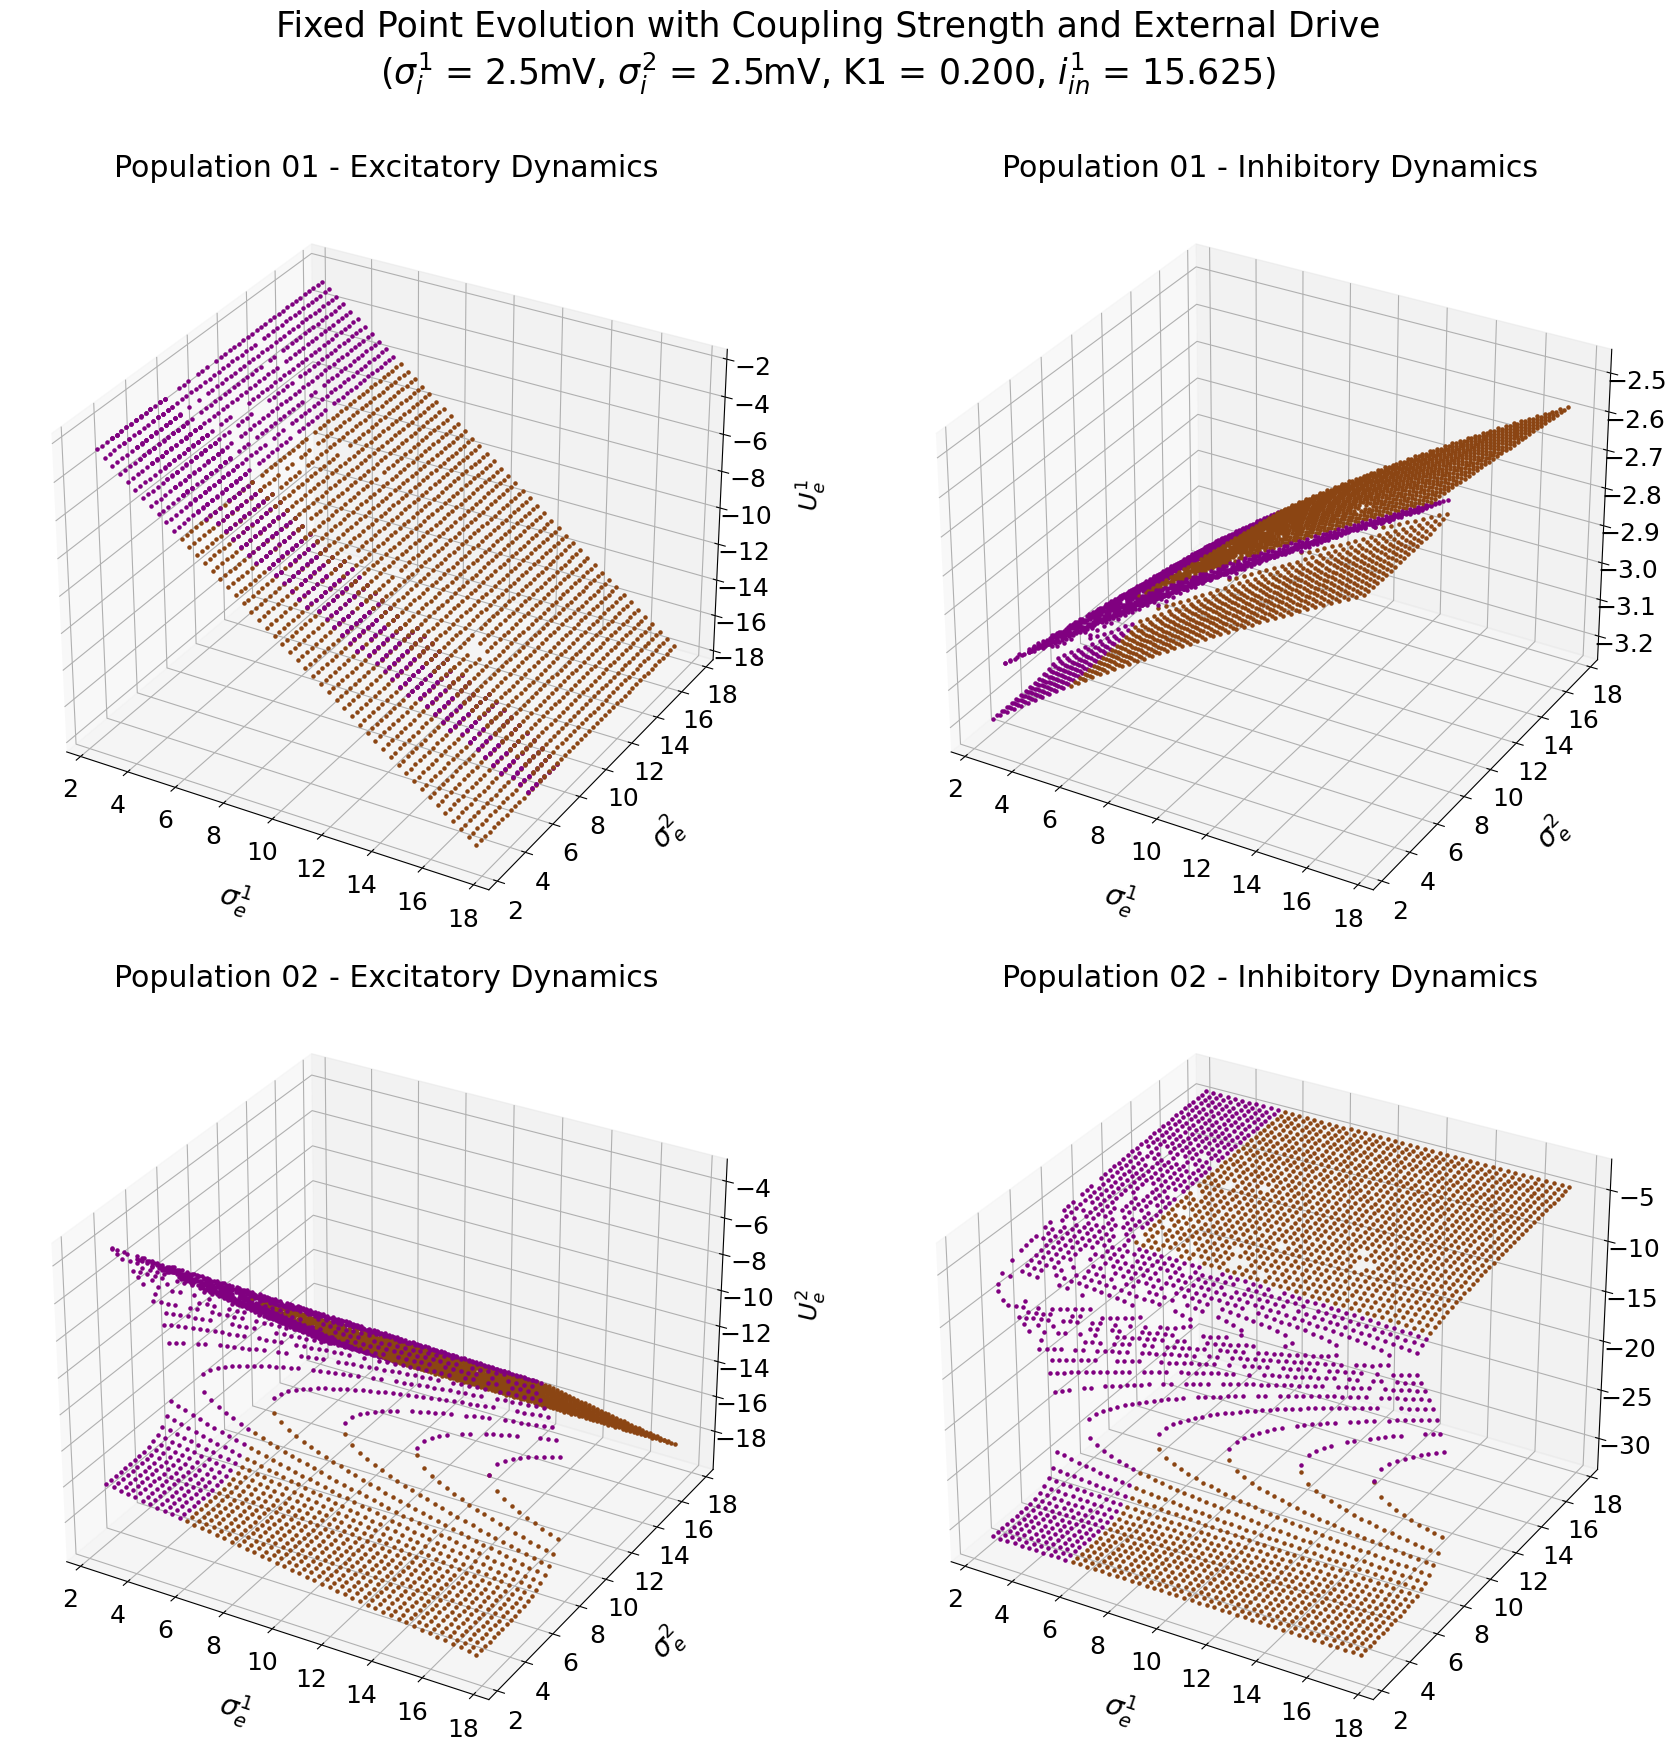

In [25]:
fig = plt.figure(figsize = (18, 18))
ax1 = fig.add_subplot(2, 2, 1, projection = '3d')
ax2 = fig.add_subplot(2, 2, 2, projection = '3d')
ax3 = fig.add_subplot(2, 2, 3, projection = '3d')
ax4 = fig.add_subplot(2, 2, 4, projection = '3d')

for e1_ in range(heterosteps):
    for e2_ in range(heterosteps):
        fixed_point = write_dict['fixed_points'][e1_][e2_]
        fixed_color = write_dict['point_type'][e1_][e2_]

        for fp, color in zip(fixed_point, fixed_color):
            sct1 = ax1.scatter3D(sigma_rng[e1_], sigma_rng[e2_], fp[0], marker='.', c = color)
            sct2 = ax2.scatter3D(sigma_rng[e1_], sigma_rng[e2_], fp[1], marker='.', c = color)
            sct3 = ax3.scatter3D(sigma_rng[e1_], sigma_rng[e2_], fp[2], marker='.', c = color)
            sct4 = ax4.scatter3D(sigma_rng[e1_], sigma_rng[e2_], fp[3], marker='.', c = color)

ax1.set_xlabel(r"$\sigma_e^1$", fontsize = 20, labelpad=20); ax1.set_ylabel(r"$\sigma_e^2$", fontsize = 20, labelpad=20); ax1.set_zlabel(r'$U_e^1$', labelpad=20)
ax1.set_title(f"Population 01 - Excitatory Dynamics")

ax2.set_xlabel(r"$\sigma_e^1$", fontsize = 20, labelpad=20); ax2.set_ylabel(r"$\sigma_e^2$", fontsize = 20, labelpad=20); ax2.set_zlabel(r'$U_i^1$', labelpad=20)
ax2.set_title(f"Population 01 - Inhibitory Dynamics")

ax3.set_xlabel(r"$\sigma_e^1$", fontsize = 20, labelpad=20); ax3.set_ylabel(r"$\sigma_e^2$", fontsize = 20, labelpad=20); ax3.set_zlabel(r'$U_e^2$', labelpad=20)
ax3.set_title(f"Population 02 - Excitatory Dynamics")

ax4.set_xlabel(r"$\sigma_e^1$", fontsize = 20, labelpad=20); ax1.set_ylabel(r"$\sigma_e^2$", fontsize = 20, labelpad=20); ax4.set_zlabel(r'$U_i^2$', labelpad=20)
ax4.set_title(f"Population 02 - Inhibitory Dynamics")

fig.suptitle(f"Fixed Point Evolution with Coupling Strength and External Drive\n" + 
             r"($\sigma_i^1$ = " + f"{parameters['sigmaI1']}mV, " + 
             r"$\sigma_i^2$ = " + f"{parameters['sigmaI2']}mV, K1 = {parameters['K1']:.3f}, " + r"$i_{in}^1$ = " + 
             f"{parameters['i_e1']/parameters['gamma']:.3f})\n", fontsize = 25)
fig.tight_layout()
fig.savefig(os.path.join(root_folder, '.'.join(file_str.split('.')[:-1])+'.png'))